# Trabalho de EST1 - G13

In [1]:
%matplotlib inline
# Importar bibliotecas
import pandas as pd

import numpy as np

from scipy.stats import shapiro, probplot, mannwhitneyu, norm

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'svg'


In [2]:
# Carrega a base salarios
salarios = pd.read_csv("salarios.csv")

# Dataset com apenas idades de esposas e maridos
df = salarios[["age", "husage"]]

In [3]:
#  As colunas de interesse tem valores em branco?
df.isna().sum()

age       0
husage    0
dtype: int64

## 1. Gráficos e Tabelas

### Elaborar os gráficos box-plot e histograma das variáveis “age” (idade da esposa) e “husage” (idade do marido) e comparar os resultados

In [4]:
# Macro definições
ROTULOS = ['Esposas', 'Maridos' ]
CORES = ['pink','lightblue' ]
FIG_SIZE = (8,5)

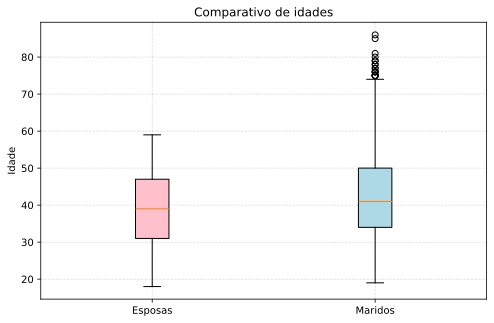

In [5]:
# Gráfico de boxplot

idade_tipos = df.to_numpy()


fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.set_ylabel('Idade')
ax.set_title("Comparativo de idades")

bplot = ax.boxplot(idade_tipos,
                   patch_artist=True,  # fill with color
                   tick_labels=ROTULOS,
                   )  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], CORES):
    patch.set_facecolor(color)
    
# Cor de fundo do gráfico (área interna)
ax.set_facecolor("white")

# Cor do fundo externo (figura inteira)
fig.patch.set_facecolor("white")

# Grade
ax.grid(True, color="gray", linestyle="--", linewidth=0.7, alpha=0.3)

plt.show()

Na distribuição de idade dos maridos é percebido uma quantidade razoável de outliers (idades acima do limite superior = Q3 + 1.5* IQR)

In [6]:
hus_IQR = df["husage"].quantile(0.75) - df["husage"].quantile(0.25)
hus_lim_sup = df["husage"].quantile(0.75) + 1.5*hus_IQR
hus_outliers = df[df["husage"] > hus_lim_sup]["husage"].count()

In [7]:
hus_outliers

np.int64(21)

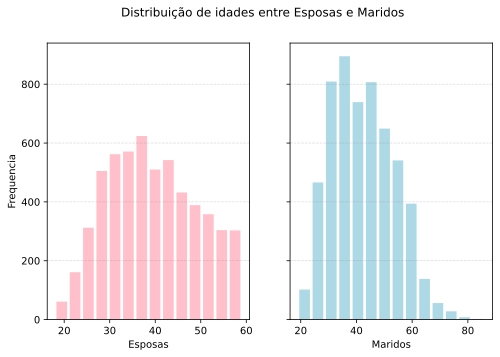

In [8]:
# Gráfico histograma usando sturges
# num_bins = 1 + log2(n) # n: número de amostras
# a implementação do numpy usa
# np.round(np.ceil(1 + np.log2(n)))
# por isso pode dar diferença de 1 em relação ao cálculo convencional de int(1+ log2(n))


# define as séries de interesse, rótulos e cores
colunas = [df['age'], df['husage']]
rotulos = ['Esposas', 'Maridos']
cores = ['pink','lightblue' ]

# cria figura e subplots
fig, axs = plt.subplots(1, 2, sharey=True, figsize=FIG_SIZE)

# estiliza para todas os subplots
for i in range(2):
    axs[i].hist(colunas[i], bins='sturges', color=CORES[i], rwidth=0.8) # cria o histograma com espaçamento entre os bins
    axs[i].set_xlabel(ROTULOS[i]) # define o rótulo da séria
    axs[i].set_facecolor('white') # cor de fundo de gráfico
    axs[i].grid(color='gray', linestyle='--', linewidth=0.7, axis='y', alpha=0.3) # seta apenas linhas de grades horizontais
    
axs[0].set_ylabel("Frequencia") # título do eixo Y apenas no gráfico da esquerda

fig.suptitle("Distribuição de idades entre Esposas e Maridos") # título da figura

plt.show()

### Elaborar a tabela de frequencias das variáveis “age” (idade da esposa) e “husage” (idade do marido) e comparar os resultados

In [9]:
# Calculando o número de classes usando a Regra de Sturges

n = len(df) # tamanho das amostras
k = int(np.round(np.ceil(1 + np.log2(n)))) # usando mesma fórmula do numpy

print(f"Número de classes (Regra de Sturges): {k}")

Número de classes (Regra de Sturges): 14


In [10]:
# Gerando a tabela de distribuição de frequência para 'age'
# Definindo os bins
bins_esp = pd.cut(df['age'], bins=k, include_lowest=True)

# Calculando a frequência absoluta e relativa
freq_abs_esp = bins_esp.value_counts().sort_index()
freq_rel_esp = bins_esp.value_counts(normalize=True).sort_index() * 100

# Criando o DataFrame da tabela de distribuição
distribution_table_esp = pd.DataFrame({
    'Frequência Absoluta': freq_abs_esp,
    'Frequência Relativa (%)': round(freq_rel_esp,2)
})

# Calculando a frequência acumulada absoluta e relativa
distribution_table_esp['Frequência Acumulada'] = distribution_table_esp['Frequência Absoluta'].cumsum()
distribution_table_esp['Frequência Relativa Acumulada (%)'] = round(distribution_table_esp['Frequência Relativa (%)'].cumsum(),2)

print("\nTabela de Distribuição de Frequência para 'age':")
display(distribution_table_esp)


Tabela de Distribuição de Frequência para 'age':


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada,Frequência Relativa Acumulada (%)
age,,,,
"(17.958, 20.929]",61,1.08,61,1.08
"(20.929, 23.857]",161,2.86,222,3.94
"(23.857, 26.786]",312,5.54,534,9.48
"(26.786, 29.714]",505,8.96,1039,18.44
"(29.714, 32.643]",562,9.98,1601,28.42
"(32.643, 35.571]",571,10.13,2172,38.55
"(35.571, 38.5]",624,11.08,2796,49.63
"(38.5, 41.429]",510,9.05,3306,58.68
"(41.429, 44.357]",542,9.62,3848,68.30


In [11]:
# Gerando a tabela de distribuição de frequência para 'husage'
# Definindo os bins
bins_mar = pd.cut(df['husage'], bins=k, include_lowest=True)

# Calculando a frequência absoluta e relativa
freq_abs_mar = bins_mar.value_counts().sort_index()
freq_rel_mar = bins_mar.value_counts(normalize=True).sort_index() * 100

# Criando o DataFrame da tabela de distribuição
distribution_table_mar = pd.DataFrame({
    'Frequência Absoluta': freq_abs_mar,
    'Frequência Relativa (%)': round(freq_rel_mar,2)
})

# Calculando a frequência acumulada absoluta e relativa
distribution_table_mar['Frequência Acumulada'] = distribution_table_mar['Frequência Absoluta'].cumsum()
distribution_table_mar['Frequência Relativa Acumulada (%)'] = round(distribution_table_mar['Frequência Relativa (%)'].cumsum(),2)

print("\nTabela de Distribuição de Frequência para 'husage':")
display(distribution_table_mar)


Tabela de Distribuição de Frequência para 'husage':


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada,Frequência Relativa Acumulada (%)
husage,,,,
"(18.932, 23.786]",102,1.81,102,1.81
"(23.786, 28.571]",466,8.27,568,10.08
"(28.571, 33.357]",809,14.36,1377,24.44
"(33.357, 38.143]",895,15.89,2272,40.33
"(38.143, 42.929]",739,13.12,3011,53.45
"(42.929, 47.714]",807,14.32,3818,67.77
"(47.714, 52.5]",649,11.52,4467,79.29
"(52.5, 57.286]",541,9.60,5008,88.89
"(57.286, 62.071]",394,6.99,5402,95.88


## 2. Medidas de posição e dispersão

### Calcular a média, mediana e moda das variáveis “age” (idade da esposa) e “husage” (idade do marido) e comparar os resultados

In [12]:
# Média das idades
media_id_esposas = df['age'].mean()
media_id_maridos = df['husage'].mean()
print(f"A idade média das esposas é: {media_id_esposas:.2f}")
print(f"A idade média dos maridos é: {media_id_maridos:.2f}")

A idade média das esposas é: 39.43
A idade média dos maridos é: 42.45


In [13]:
# A media da idade das esposas é 39.43
# A media da idade dos maridos é 42.45

# se dividirmos a idade médias maridos pela das esposas
# temos
print(f"{(media_id_maridos/media_id_esposas)-1:.2%}")

# Portanto, a idade média dos maridos 7.67% maior que das esposas

7.67%


In [14]:
# Mediana das idades
mediana_id_esposas = df['age'].median()
mediana_id_maridos = df['husage'].median()
print(f"A mediana da idade das esposas é: {mediana_id_esposas:.2f}")
print(f"A mediana da idade dos maridos é: {mediana_id_maridos:.2f}")

A mediana da idade das esposas é: 39.00
A mediana da idade dos maridos é: 41.00


In [15]:
# A mediana da idade das esposas é 39
# A mediana da idade dos maridos é 41

# se dividirmos a mediana da idade dos maridos pela das esposas
# temos
print(f"{(mediana_id_maridos/mediana_id_esposas)-1:.2%}")

# Portanto, a mediana da idade dos maridos 5.13% maior que das esposas

5.13%


In [16]:
# A Moda das idades
moda_id_esposas = df['age'].mode()[0]
moda_id_maridos = df['husage'].mode()[0]
print(f"A moda da idade das esposas é: {moda_id_esposas:.2f}")
print(f"A moda da idade dos maridos é: {moda_id_maridos:.2f}")

A moda da idade das esposas é: 37.00
A moda da idade dos maridos é: 44.00


In [17]:
# A moda da idade das esposas é 37
# A moda da idade dos maridos é 44

# se dividirmos a moda da idade dos maridos pela das esposas
# temos
print(f"{(moda_id_maridos/moda_id_esposas)-1:.2%}")

# Portanto, a moda da idade dos maridos 18.92% maior que das esposas

18.92%


### Calcular a variância, desvio padrão e coeficiente de variação das variáveis “age” (idade da esposa) e “husage” (idade do marido) e comparar os resultados

In [18]:
# A Variância
var_id_esposas = df['age'].var()
var_id_maridos = df['husage'].var()
print(f"A variância da idade das esposas é: {var_id_esposas:.2f}")
print(f"A vairância da idade dos maridos é: {var_id_maridos:.2f}")

A variância da idade das esposas é: 99.75
A vairância da idade dos maridos é: 126.07


In [19]:
# A variância da idade das esposas é 99.75
# A variância da idade dos maridos é 126,07

# se dividirmos a variância da idade dos maridos pela das esposas
# temos
print(f"{(var_id_maridos/var_id_esposas)-1:.2%}")

# Portanto, a variância da idade dos maridos 26.38% maior que das esposas

26.38%


In [20]:
# Desvio padrão
std_id_esposas = df['age'].std()
std_id_maridos = df['husage'].std()
print(f"O desvio padrão da idade das esposas é: {std_id_esposas:.2f}")
print(f"O desvio padrão da idade dos maridos é: {std_id_maridos:.2f}")

O desvio padrão da idade das esposas é: 9.99
O desvio padrão da idade dos maridos é: 11.23


In [21]:
# O desvio padrão da idade das esposas é 9.99
# O desvio padrão da idade dos maridos é 11.23

# se dividirmos o desvio padrão da idade dos maridos pela das esposas
# temos
print(f"{(std_id_maridos/std_id_esposas)-1:.2%}")

# Portanto, o desvio padrão da idade dos maridos é  12.42% maior que das esposas

12.42%


In [22]:
# Coeficiente de variação
cv_id_esposas = std_id_esposas / media_id_esposas
cv_id_maridos = std_id_maridos / media_id_maridos
print(f"O coeficiente de variação da idade das esposas é: {cv_id_esposas:.2%}")
print(f"O coeficiente de variação da idade dos maridos é: {cv_id_maridos:.2%}")

O coeficiente de variação da idade das esposas é: 25.33%
O coeficiente de variação da idade dos maridos é: 26.45%


In [23]:
# O coeficiente de variação da idade das esposas é: 25.33%
# O coeficiente de variação da idade dos maridos é: 26.45%

# se dividirmos o CV da idade dos maridos pela das esposas
# temos
print(f"{(cv_id_maridos/cv_id_esposas)-1:.2%}")

# Portanto, coeficiente de variação da idade dos maridos é  4.41% maior que das esposas

4.41%


## 3. Testes paramétricos ou não paramétricos

Testar se as médias (se você escolher o teste paramétrico) ou as medianas (se você
	escolher o teste não paramétrico) das variáveis “age” (idade da esposa) e “husage” (idade do
	marido) são iguais, construir os intervalos de confiança e comparar os resultados.
	Obs:
	
1. Você deve fazer os testes necessários (e mostra-los no documento pdf) para saber se você
		deve usar o unpaired test (paramétrico) ou o teste U de Mann-Whitney (não paramétrico),
		justifique sua resposta sobre a escolha.
2. Lembre-se de que os intervalos de confiança já são mostrados nos resultados dos testes
		citados no item 1 acima.
	

A decisão de usar um tipo de teste ou outro depende da natureza das amostras  

Se forem normalmente distribuidas é melhor o teste paramétrico  

Primeiro verificamos se as amostras seguem uma distribuição normal

In [24]:
# Separar as amostras em dois vetores
x1 = df['age'].to_numpy() # idade das esposas
x2 = df['husage'].to_numpy() # idade dos maridos

In [25]:
# verifica se são normalmente distribuidas
_, pvalue1 = shapiro(x1)
_, pvalue2 = shapiro(x2)
print(f"A amostra  x1 é normalmente distribuida ? {pvalue1 >= 0.05}")
print(f"A amostra  x2 é normalmente distribuida ? {pvalue2 >= 0.05}")

A amostra  x1 é normalmente distribuida ? False
A amostra  x2 é normalmente distribuida ? False


Como as amostras não são normalmente distribuidas, não podemos fazer testes paramétricos

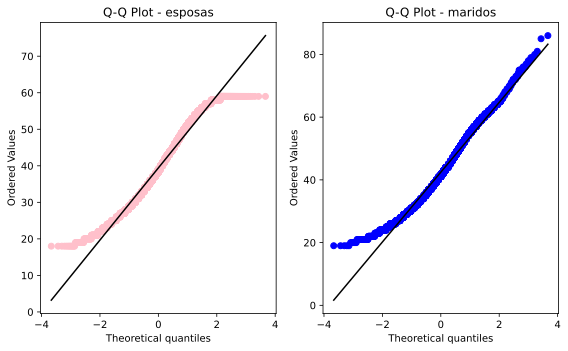

In [26]:
# Mostra os gráficos Q-Q de cada amostra

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

probplot(x1, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot - esposas")
# alterar cores
axes[0].lines[0].set_color("pink")   # pontos
axes[0].lines[1].set_color("black")  # linha

probplot(x2, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot - maridos")
axes[1].lines[0].set_color("blue")
axes[1].lines[1].set_color("black")

plt.tight_layout()


In [27]:
# Teste de Mann-Whitney U (Não paramétrico)
stat, p_valor = mannwhitneyu(x1, x2, alternative="two-sided")
print(f"Mann-Whitney U: Estatística = {stat:.4f}, p-valor = {p_valor:.4f}")

Mann-Whitney U: Estatística = 13619912.0000, p-valor = 0.0000


Como o p-value é menor que 0.05, rejeitamos a hipótese que as medianas são estatisticamente iguais

In [28]:
def hodges_lehmann_ci(x, y, alpha=0.05):
    """Função para calcular o intervalo de confiança"""

    x = np.array(x)
    y = np.array(y)

    m = len(x)
    n = len(y)

    # todas as diferenças
    diffs = np.array([xi - yi for xi in x for yi in y])
    diffs.sort()

    # estimador Hodges–Lehmann
    hl = np.median(diffs)

    N = m * n

    # encontrar k usando distribuição de U

    # aproximação via normal
    mu = N / 2
    sigma = np.sqrt(m*n*(m+n+1)/12)

    z = norm.ppf(1 - alpha/2)

    u = int(np.floor(mu - z*sigma))

    k = max(1, u + 1)

    lower = diffs[k-1]
    upper = diffs[N-k]

    return hl, (lower.item(), upper.item())



In [29]:
hl, ci = hodges_lehmann_ci(x2,x1)

print("Hodges-Lehmann:", hl)
print("IC 95%:", ci)

Hodges-Lehmann: 3.0
IC 95%: (2, 3)


No intervalo de confiança [2, 3] não contempla zero, portanto existe diferença significativa entre as medianas.